In [2]:
import pandas as pd 
import numpy as np 

df = pd.read_csv('car_prices.csv')
df.head(3)

,car_id,mileage,selling_price
0,A001,126958,9734
1,A002,151867,8775
2,A003,136932,3928


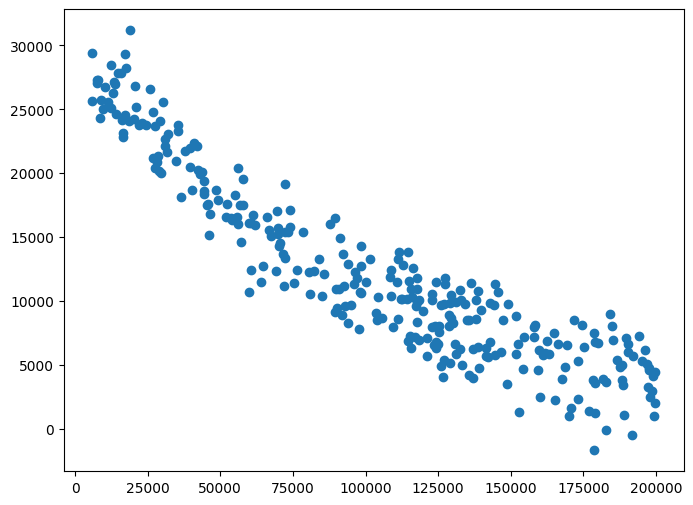

In [3]:
from matplotlib import pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df.mileage, df.selling_price)
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

x = df[['mileage']]
y = df['selling_price']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=5)


In [7]:
x.shape,x.size

((300, 1), 300)

In [10]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
x_test_poly = poly.fit_transform(x_test)

In [11]:
x_test_poly[:5]

array([[1.00000000e+00, 2.44570000e+04, 5.98144849e+08],
       [1.00000000e+00, 9.83840000e+04, 9.67941146e+09],
       [1.00000000e+00, 3.97540000e+04, 1.58038052e+09],
       [1.00000000e+00, 1.03506000e+05, 1.07134920e+10],
       [1.00000000e+00, 1.89779000e+05, 3.60160688e+10]])

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score

model = LinearRegression()
model.fit(x_test_poly,y_test)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
y_pred = model.predict(x_test_poly)

mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
mse,r2

(3781837.114715991, 0.9195612532615047)